<div style = "text-align: center">
    <img src = "Banner.png" width = "100%" style = "border: solid; border-radius: 10px"></img>
</div>

<h1 style = 'text-align: center;'>Problemas de Fluxos em Redes:<br>Grafos e o Problema do Caminho Mínimo</h1>

por **Elias Helou**

**ICMC/USP - São Carlos SP**

<h2>Conteúdo do vídeo</h2>

1. Grafos

2. O Problema do caminho mínimo

3. Formulação binária

## 1. Grafos

O conceito de grafo tem importância fundamental em matemática pura e aplicada pois, apesar da sua simplicidade, grafos são capazes de modelar situações complexas que dão origem a sofisticadas propriedades emergentes. Algumas das aplicações de grafos são

- Ciência da computação

- Física, medicina, biologia (normalmente através de redes complexas)

- Economia

- Logística

No nosso caso, iremos nos concentrar em problemas de logística que são modelados através de grafos. Muitos desses são conhecidos como problemas de fluxos em redes.

Um grafo consiste de um conjunto de vértices (ou nós)
$$
    V = \{ 1, 2, \dots, N \}
$$
e de um conjunto de arestas
$$
    E \subset V \times V.
$$

Grafos são comumente representados graficamente como uma rede de vértices interligados pelas arestas. A seguir vemos um exemplo de uma possível representação de um grafo com
$$
    V = \{ 1, 2, 3, 4, 5 \}
$$
e
$$
    E = \{ ( 1, 2 ), ( 1, 3 ), ( 1, 5 ), ( 2, 3 ), ( 3, 4 ), ( 4, 5 ) \}.
$$

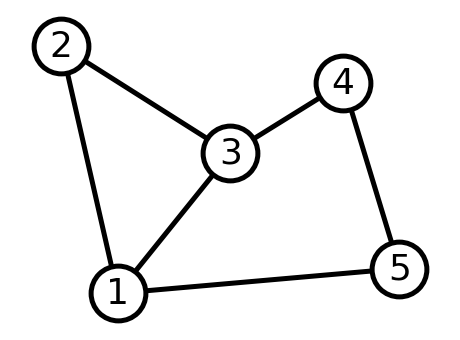

In [1]:
# Exemplo adaptado da documentação do NetworkX
# https://networkx.org/documentation/stable/auto_examples/basic/plot_simple_graph.html#sphx-glr-auto-examples-basic-plot-simple-graph-py
 
import networkx as nx
import matplotlib.pyplot as pp

# Exemplo adaptado da documentação do networkx

G = nx.Graph()
G.add_edge( 1, 2 )
G.add_edge( 1, 3 )
G.add_edge( 1, 5 )
G.add_edge( 2, 3 )
G.add_edge( 3, 4 )
G.add_edge( 4, 5 )

# Posições do vértices
pos = { 1: (0, 0), 2: (-1, 0.3), 3: (2, 0.17), 4: (4, 0.255), 5: (5, 0.03) }

options = {
    "font_size": 36,
    "node_size": 3000,
    "node_color": "white",
    "edgecolors": "black",
    "linewidths": 5,
    "width": 5,
}

pp.figure( figsize = ( 8, 6 ) )
nx.draw_networkx( G, pos, **options )
pp.margins( 0.1 )
pp.axis( 'off' )
pp.show()

### 1.1. Grafos Direcionados

O grafo acima é um exemplo de grafo não-direcionado. Grafos direcionados (ou dígrafos) são grafos onde as arestas possuem direção.

Por exemplo, consideremo o grafo com
$$
    V = \{ 1, 2, 3, 4, 5, 6, 7 \}
$$
e
$$
    E = \{ ( 1, 4 ), ( 2, 4 ), ( 3, 5 ), ( 4, 6 ), ( 4, 7 ), ( 5, 7 ), ( 6, 7 ), ( 7, 4 ) \}.
$$

Observe que temos as arestas $( 4, 7 )$ e $( 7, 4 )$.

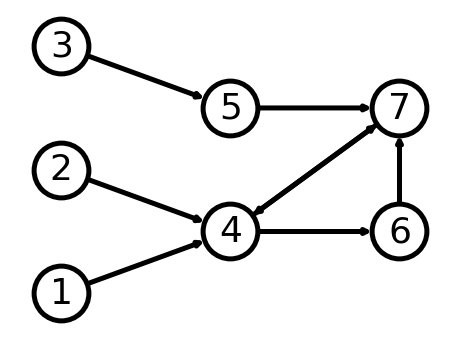

In [2]:
# Exemplo adaptado da documentação do NetworkX
# https://networkx.org/documentation/stable/auto_examples/basic/plot_simple_graph.html#sphx-glr-auto-examples-basic-plot-simple-graph-py

import networkx as nx
import matplotlib.pyplot as pp

G = nx.DiGraph(
    [ ( 1, 4 ), ( 2, 4 ), ( 3, 5 ), ( 4, 6 ), ( 4, 7 ), ( 5, 7 ), ( 6, 7 ), ( 7, 4 ) ]
)

# Agrupa nós por colunas
left_nodes = [ 1, 2, 3 ]
middle_nodes = [ 4, 5 ]
right_nodes = [ 6, 7 ]

# Ajusta coordenada x por colunas
pos = { n: ( 0, i ) for i, n in enumerate( left_nodes ) }
pos.update( { n: (1, i + 0.5) for i, n in enumerate( middle_nodes ) } )
pos.update( {n: (2, i + 0.5) for i, n in enumerate( right_nodes ) } )

options = {
    "font_size": 36,
    "node_size": 3000,
    "node_color": "white",
    "edgecolors": "black",
    "linewidths": 5,
    "width": 5,
}

pp.figure( figsize = ( 8, 6 ) )
nx.draw_networkx( G, pos, **options )
pp.margins( 0.1 )
pp.axis( 'off' )
pp.show()

Algumas observações:

1. Nem sempre as posições dos nós são pré-determinadas

2. Pode haver nós ou subgrafos isolados

3. Em casos realistas, o número de nós e arestas pode ser gigantesco

## 2. O Problema do Caminho Mínimo

Um dígrafo pode representar uma rede viária onde os nós são pontos intermediários e as arestas são trechos de ruas interligando esses pontos. Neste caso, podemos desejar ir de um ponto a outro de forma a minimizar a distância percorrida. Nos nossos problemas, a origem será o nó denotado por
$$
    o \in V
$$
e o destino será o nó denotado por 
$$
    d \in V.
$$

Para modelar este problema, precisamos associar pesos a cada aresta para representar o custo de ir de um nó para outro. O modelo completo exige, portanto, além do dígrafo, da origem e do destino, uma função peso:
$$
    V = \{ 1, 2, \dots, N \},
$$
$$
    E \subset V \times V,
$$
$$
    f: E \to \mathbb R.
$$

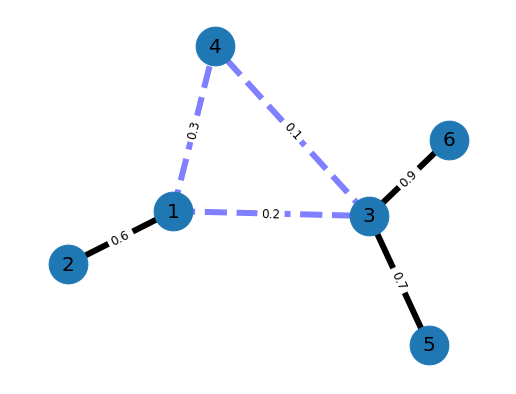

In [3]:
# Exemplo adaptado da documentação do NetworkX
# https://networkx.org/documentation/stable/auto_examples/drawing/plot_weighted_graph.html

import networkx as nx
import matplotlib.pyplot as pp

G = nx.Graph()

G.add_edge( 1, 2, weight = 0.6 )
G.add_edge( 1, 3, weight = 0.2 )
G.add_edge( 3, 4, weight = 0.1 )
G.add_edge( 3, 5, weight = 0.7 )
G.add_edge( 3, 6, weight = 0.9 )
G.add_edge( 1, 4, weight = 0.3 )

elarge = [ ( u, v ) for ( u, v, d ) in G.edges( data = True ) if d[ 'weight' ] > 0.5 ]
esmall = [ ( u, v ) for ( u, v, d ) in G.edges( data = True ) if d[ 'weight' ] <= 0.5 ]

pos = nx.spring_layout( G, seed = 0 )

pp.figure( figsize = ( 9, 7 ) )

nx.draw_networkx_nodes( G, pos, node_size = 1500 )

nx.draw_networkx_edges( G, pos, edgelist = elarge, width = 6 )
nx.draw_networkx_edges( G, pos, edgelist = esmall, width = 6, alpha = 0.5, edge_color = 'b', style = 'dashed' )

nx.draw_networkx_labels( G, pos, font_size = 20, font_family = 'sans-serif' )

edge_labels = nx.get_edge_attributes( G, 'weight' )
nx.draw_networkx_edge_labels( G, pos, edge_labels, font_size = 12, font_family = 'sans-serif' )

pp.margins( 0.1 )
pp.axis( 'off' )
pp.show()


O grafo acima é muito pequeno. Abaixo vemos um exemplo com um número de nós mais realista.

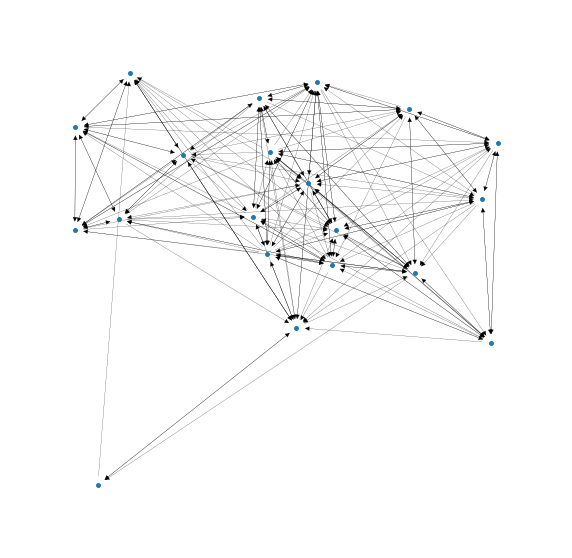

DiGraph with 20 nodes and 194 edges


In [4]:
import networkx as nx
import matplotlib.pyplot as pp
import numpy as np

N = 20

# Gera N pontos aleatórios no quadrado [ 0, 1 ] x [ 0, 1 ]
np.random.seed( 0 )
pos = {}
for i in range( 1, N + 1 ):
    pos[ i ] = tuple( np.random.uniform( size = ( 2, ) ) )

# Conecta vértices com probabilidade proporcional à distância
G = nx.DiGraph()
for i in range( 1, N + 1 ):
    for j in range( 1, N + 1 ):
        d = (
            ( pos[ i ][ 0 ] - pos[ j ][ 0 ] ) ** 2 +
            ( pos[ i ][ 1 ] - pos[ j ][ 1 ] ) ** 2
        ) ** 0.5

        r = np.random.uniform()
        if ( i != j ) and ( d < r ):
            G.add_edge( i, j, weight = d )

pp.figure( figsize = ( 10, 10 ) )

nx.draw_networkx_nodes( G, pos, node_size = 15 )
nx.draw_networkx_edges( G, pos, width = 0.2 )

pp.margins( 0.1 )
pp.axis( 'off' )
pp.show()

print( G )

## 3. Formulação Binária do Problema de Caminho Mínimo

Iremos denotar as variáveis de decisão por
$$
        x_{i, j} \in \{ 0, 1 \} \quad\text{para todo } ( i, j ) \in E.
$$


Ou seja, para cada aresta do grafo haverá uma variável de decisão *binária* que vale
$$
        x_{i, j} = \begin{cases}
                        1 & \text{se o caminho passa pela aresta }( i, j )\\
                        0 & \text{caso contrário.}
                   \end{cases}
$$

Um caminho sai de $o$, então é necessário que haja exatamente uma aresta do caminho partindo de $o$
$$
        \sum_{( o, j ) \in E}x_{o, j} = 1.
$$
Da mesma forma, é necessário que haja exatamente uma aresta do caminho chegando a $d$:
$$
        \sum_{( i, d ) \in E}x_{i, d} = 1.
$$
Para todo outros nó $k$, se um caminho chega até $k$, ele tem que sair de $k$:
$$
        \sum_{( i, k ) \in E}x_{i, k} = \sum_{( k, j ) \in E}x_{k, j}\quad \forall k \in V \setminus \{o, d\}.
$$

Levando em conta o custo de percorrer cada aresta, teremos o problema
$$
\begin{align*}
        \min       & \quad \sum_{( i, j ) \in E} f( i, j )x_{i, j}\\
        \text{s.a:}& \quad \sum_{( o, j ) \in E}x_{o, j} = 1\\
                   & \quad \sum_{( i, d ) \in E}x_{i, d} = 1\\
                   & \quad \sum_{( i, k ) \in E}x_{i, k} = \sum_{( k, j ) \in E}x_{k, j} &\quad \forall k \in V \setminus \{o, d\}\\
                   & \quad x_{i, j} \in \{ 0, 1 \} \quad &\forall ( i, j ) \in E.
\end{align*}
$$

Uma forma interessante e útil de escrever esse problema é
$$
\begin{align*}
        \min       & \quad \sum_{( i, j ) \in E} f( i, j )x_{i, j}\\
        \text{s.a:}& \quad \sum_{( i, k ) \in E}x_{i, k} - \sum_{( k, j ) \in E}x_{k, j} = \begin{cases}1 &\text{se } k = d\\ -1 &\text{se } k = o\\ 0 & \text{caso contrário}\end{cases} &\quad \forall k \in V\\
                   & \quad x_{i, j} \in \{ 0, 1 \} \quad &\forall ( i, j ) \in E.
\end{align*}
$$


- Problemas binários são difíceis de resolver

- Existem algoritmos muito eficientes específicos para este problema

- Restrições da forma abaixo, para $k$ fixo, são conhecidas como restições de conservação do fluxo
$$
    \sum_{( i, k ) \in E}x_{i, k} - \sum_{( k, j ) \in E}x_{k, j} = 0.
$$

- É possível formular como um problema de otimização linear trocando a última restrição por
$$
    x_{i, j} \ge 0 \quad \forall ( i, j ) \in E
$$
